# Машинное обучение

# Домашнее задание 2. Обучение без учителя, кластеризация.

## Общая информация
Дата выдачи: 02.10.2025

Дедлайн: 16.10.2025 23:59 MSK

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи).

Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.


## О задании

В этом задании мы посмотрим на несколько алгоритмов кластеризации и применим их к текстовым данным. Также мы подробно остановимся на тематическом моделировании текстов, задаче обучения представлений и в каком-то смысле поработаем с semi-supervised learning.

In [1]:
import pandas as pd
import numpy as np

np.random.seed(0xFFFFFFF)

## Часть 1. Тематическое моделирование текстов

В этой части мы познакомимся с одной из самых популярных задач обучения без учителя &mdash; с задачей тематического моделирования текстов. Допустим, нам доступна некоторая коллекция документов без разметки, и мы хотим автоматически выделить несколько тем, которые встречаются в документах, а также присвоить каждому документу одну (или несколько) тем. Фактически, мы будем решать задачу, похожую на кластеризацию текстов: отличие в том, что нас будет интересовать не только разбиение текстов на группы, но и выделение ключевых слов, определяющих каждую тему.

Мы будем работать с новостными статьями BBC за 2004-2005 годы. Скачайте данные по [ссылке](https://www.kaggle.com/hgultekin/bbcnewsarchive).

In [23]:
data = pd.read_csv('bbc-news-data.csv', sep='\t')
data.sample(5)

,category,filename,title,content
1900,tech,077.txt,Rich pickings for hi-tech thieves,"Viruses, trojans and other malicious programs..."
357,business,358.txt,Deutsche attacks Yukos case,German investment bank Deutsche Bank has chal...
1975,tech,152.txt,New Year's texting breaks record,A mobile phone was as essential to the recent...
829,entertainment,320.txt,Johnny Cash manager Holiff dies,"The former manager of Johnny Cash, Saul Israe..."
21,business,022.txt,Sluggish economy hits German jobs,The number of people out of work in Europe's ...


Как вы могли заметить, данные уже содержат разметку по тематике (колонка category). В этой части мы забудем, что она есть, и будем работать только с текстовыми данными. Проведем предобработку текста, состоящую из следующих пунктов:

* Объединим заголовок и содержание статьи в одно поле.
* Приведем текст к нижнему регистру, разобьем его на токены.
* Оставим только буквенные слова (удалив, таким образом, пунктуацию и числа).
* Применим лемматизацию.
* Удалим стоп-слова.


In [3]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [22]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

stop_words = set(stopwords.words('english') + ['ha', 'wa', 'say', 'said'])
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [24]:
def preprocess(text):
    text = list(filter(str.isalpha, word_tokenize(text.lower())))
    text = list(lemmatizer.lemmatize(word) for word in text)
    text = list(word for word in text if word not in stop_words)
    return ' '.join(text)

In [6]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [25]:
data['raw_text'] = data.apply(lambda row: row.title + row.content, axis=1)
data['text'] = data.apply(lambda row: preprocess(row.raw_text), axis=1)

Для визуализации частот слов в текстах мы будем использовать [облака тегов](https://en.wikipedia.org/wiki/Tag_cloud).

In [26]:
from wordcloud import WordCloud

def draw_wordcloud(texts, max_words=1000, width=1000, height=500):
    wordcloud = WordCloud(background_color='white', max_words=max_words,
                          width=width, height=height)

    joint_texts = ' '.join(list(texts))
    wordcloud.generate(joint_texts)
    return wordcloud.to_image()

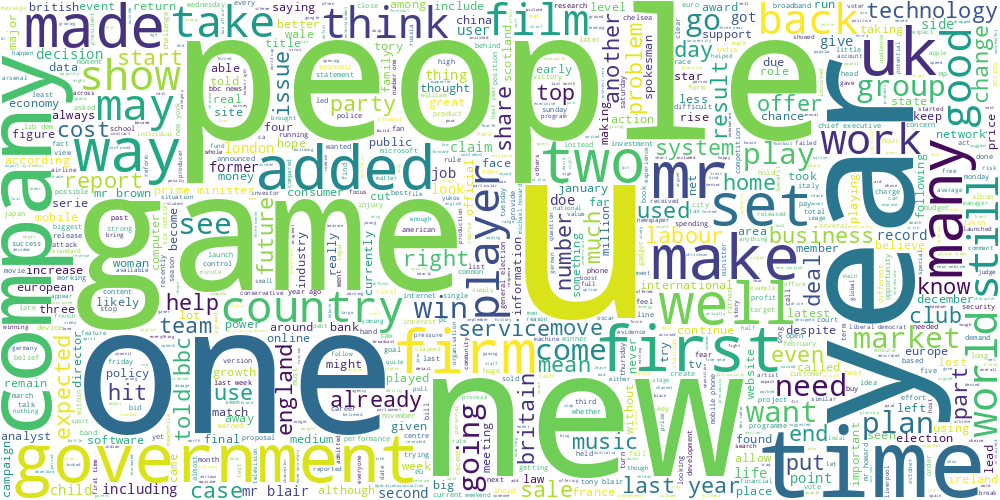

In [27]:
draw_wordcloud(data.text)

**Задание 1.1 (1 балл).** Обучите алгоритм K-Means на tf-idf представлениях текстов. При обучении tf-idf векторайзера рекомендуется отбрасывать редко встречающиеся слова, а также воздержитесь от использования N-грамм. Возьмите не очень большое число кластеров, чтобы было удобно интерпретировать получившиеся темы (например, `n_clusters` = 8). Постройте облака тегов для текстов из разных кластеров. Получились ли темы интерпретируемыми? Попробуйте озаглавить каждую тему.

**Ответ:** Да, получились. 1. Кино 2. Технологии 3. Экономика и энергетика 4. Спорт 5. Бизнес 6. Политика 7. Право 8. Музыка и развлечения

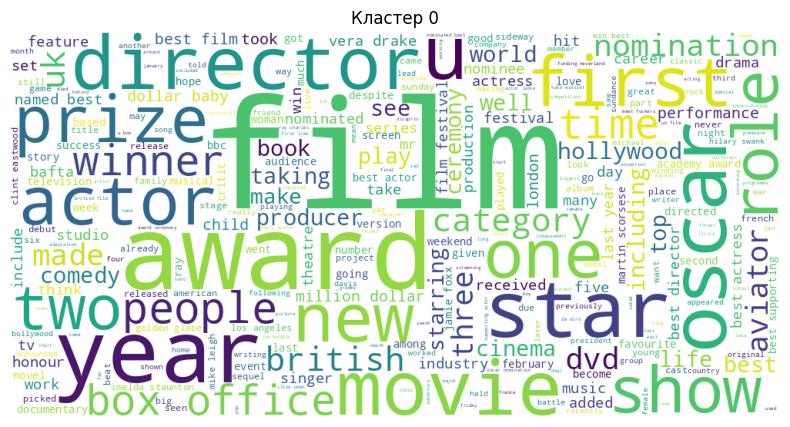

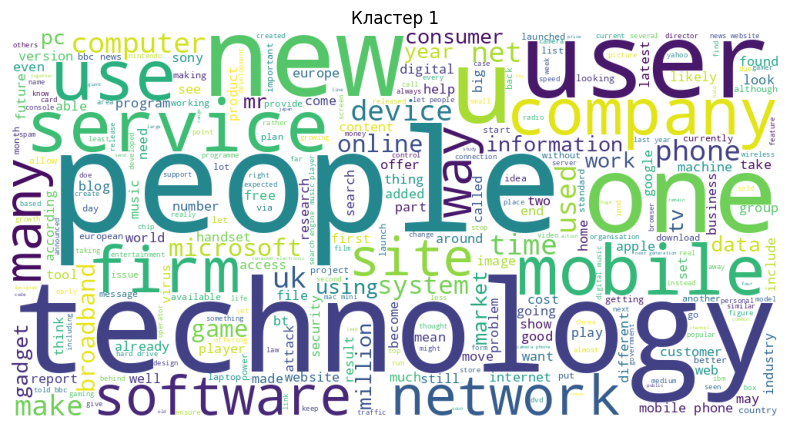

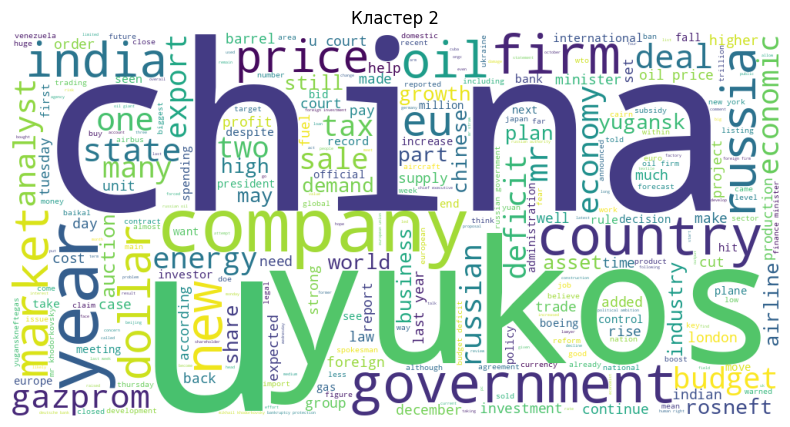

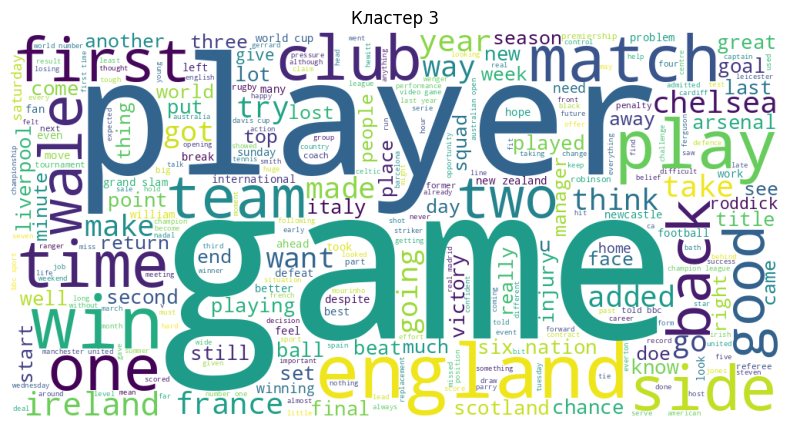

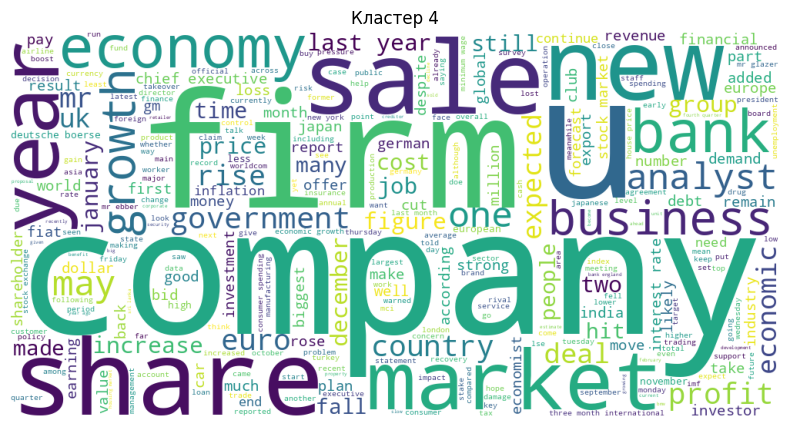

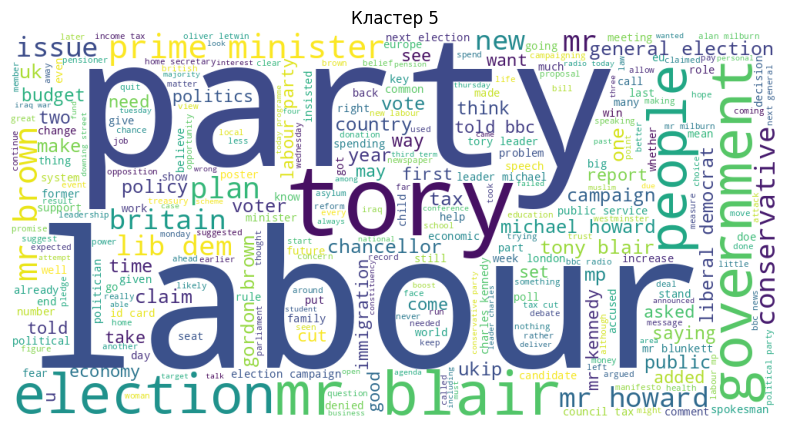

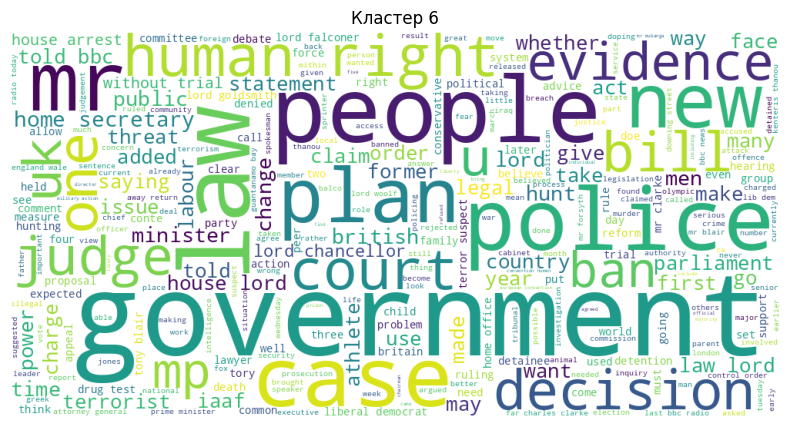

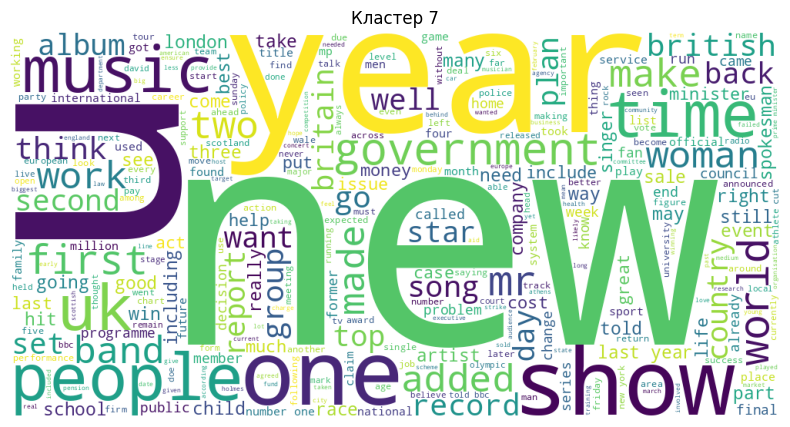

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.7,
    ngram_range=(1, 1)
)
X = vectorizer.fit_transform(data['text'])
terms = vectorizer.get_feature_names_out()

n_clusters = 8
kmeans = KMeans(n_clusters=8, random_state=42, n_init='auto')
data['cluster'] = kmeans.fit_predict(X)

for c in range(n_clusters):
    texts_c = data.loc[data.cluster == c, 'text']
    img = draw_wordcloud(texts_c, max_words=300, width=1000, height=500)
    plt.figure(figsize=(10,5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Кластер {c}')
    plt.show()

order = kmeans.cluster_centers_.argsort(axis=1)[:, ::-1]

**Задание 1.2 (1 балл).** Попробуем другой способ выделить ключевые слова для каждой темы. Помимо непосредственного разбиения объектов алгоритм K-Means получает центр каждого кластера. Попробуйте взять центры кластеров и посмотреть на слова, для которых значения соответствующих им признаков максимальны. Согласуются ли полученные слова с облаками тегов из прошлого задания?

**Ответ:** Да, заметно, что темы согласуются.

In [32]:
centers = kmeans.cluster_centers_

num_top_words = 5
for c in range(n_clusters):
  top_indices = centers[c].argsort()[::-1][:num_top_words]
  top_words = [terms[i] for i in top_indices]
  print(f'{c+1}. {", ".join(top_words)}')

1. film, award, best, oscar, actor
2. mobile, phone, technology, people, user
3. oil, china, yukos, price, deficit
4. game, england, player, match, win
5. bank, growth, share, market, economy
6. mr, labour, election, party, blair
7. lord, law, police, court, government
8. year, show, music, band, mr


**Задание 1.3 (2 балла).** Посмотрим на кластеризацию для текстовых данных (в качестве признакого описания снова используем tf-idf). Получите три разбиения на кластеры с помощью алгоритмов K-Means, DBSCAN и спектральной кластеризации (на этот раз воспользуйтесь реализацией из `sklearn`). Для K-Means и спектральной кластеризации возьмите одинаковое небольшое число кластеров, подберите параметр `eps` метода DBSCAN так, чтобы получить приблизительно такое же число кластеров.

Далее, обучите двухмерные t-SNE представления над tf-idf признаками текстов. Визуализируйте эти представления для каждого алгоритма, раскрасив каждый кластер своим цветом. Лучше всего расположить визуализации на одном графике на трех разных сабплотах. Не забудьте, что DBSCAN помечает некоторые точки как шумовые (можно раскрасить их в отдельный цвет).

eps=0.38


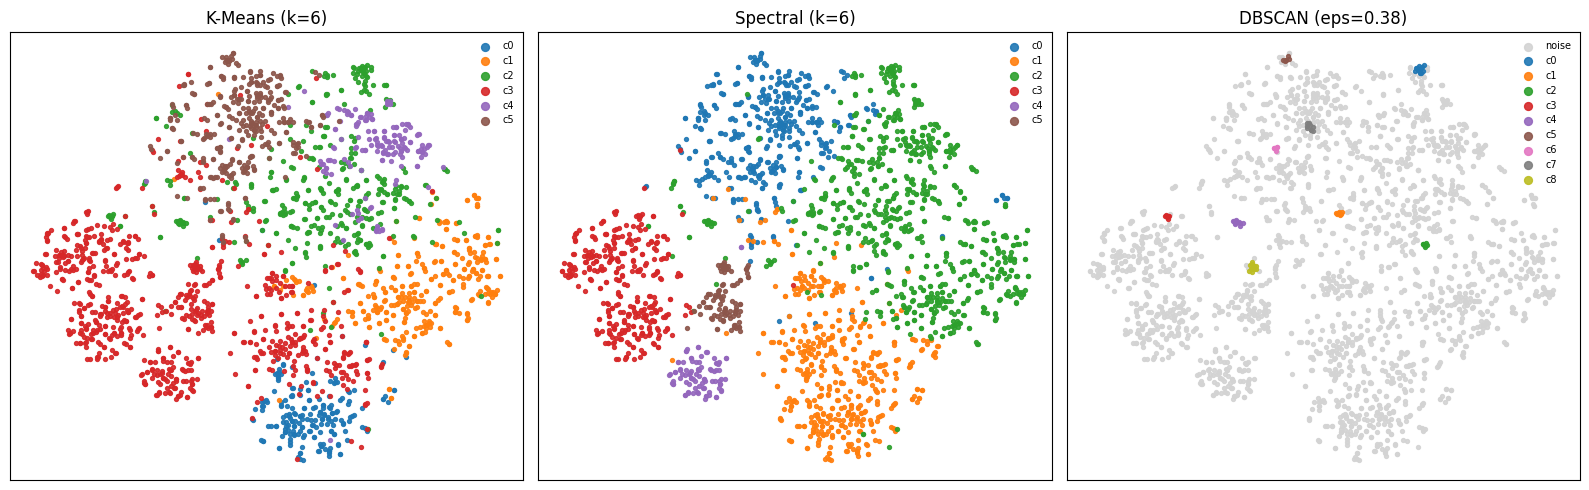

In [34]:
from sklearn.manifold import TSNE
from sklearn.cluster import SpectralClustering, DBSCAN

X = TfidfVectorizer(min_df=5, max_df=0.7, ngram_range=(1,1)).fit_transform(data['text'])

target_k = 8
eps_values = np.linspace(0.1, 1.0, 20)
best_eps, best_labels, best_diff = None, None, float('inf')

for eps in eps_values:
  labels = DBSCAN(eps=eps, min_samples=5, metric='cosine').fit_predict(X)
  n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
  diff = abs(n_clusters - target_k)
  if n_clusters > 1 and diff < best_diff:
    best_eps, best_labels, best_diff = eps, labels, diff

print(f"eps={best_eps:.2f}")

X_2d = TSNE(
    n_components=2, random_state=42, perplexity=30,
    init='pca', learning_rate='auto'
).fit_transform(X.toarray())

k = 6
labels_km = KMeans(n_clusters=k, random_state=42, n_init='auto').fit_predict(X)
labels_sc = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', n_neighbors=15,
                               assign_labels='kmeans', random_state=42).fit_predict(X)
labels_db = best_labels

def plot(ax, labels, title):
  uniq = np.unique(labels)
  for lab in uniq:
    mask = labels == lab
    color = 'lightgray' if lab == -1 else None
    lbl = 'noise' if lab == -1 else f'c{lab}'
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=8, c=color, label=lbl, alpha=0.9)
  ax.set_title(title)
  ax.set_xticks([]); ax.set_yticks([])
  ax.legend(markerscale=2, fontsize=7, frameon=False)

fig, axs = plt.subplots(1, 3, figsize=(16,5))
plot(axs[0], labels_km, f'K-Means (k={k})')
plot(axs[1], labels_sc, f'Spectral (k={k})')
plot(axs[2], labels_db, f'DBSCAN (eps={best_eps:.2f})')
plt.tight_layout()
plt.show()

Прокомментируйте получившиеся результаты. Какой баланс кластеров получился у разных методов? Соотносятся ли визуализации для текстов с визуализациями для географических данных?

**Ответ:** K-means и spectral clustering создали относительно равномерное распределение документов по кластерам, а вот DBSCAN дал неравномерные кластеры, многие документы признаны шумом. K-means создал кластеры с наслоением, можно привести аналогию с реками и морями, spectral cl. без наслоений, аналогия с картой стран, DBSCAN например столицы стран.

**Задание 1.4 (2 балла).** Обучите модель латентного размещения Дирихле. Не забудьте, что она работает с мешком слов, а не с tf-idf признаками. Придумайте, как превратить распределение тем для текста в номер его кластера. Возьмите параметр `n_components` в 2-3 раза больше, чем число кластеров для K-Means. Получились ли темы более узкими от такого нововведения? Постройте облака тегов для нескольких наиболее удачных тем.

**Ответ:** Темы тепеперь стали более узкими, теперь есть темы про конкретные виды спорта, например.

 0: lord, mr, police, home, people, law, government, plan, new, told, house, right
 1: year, firm, airline, new, market, gm, fiat, air, flight, cost, robot, company
 2: china, india, bank, country, ukip, indian, company, eu, wage, exchange, patent, law
 3: film, best, award, year, star, actor, director, oscar, world, british, new, actress
 4: mr, labour, party, election, blair, brown, tory, minister, prime, howard, chancellor, leader
 5: mobile, phone, number, camera, people, uk, year, handset, box, office, film, service
 6: game, win, player, time, play, match, cup, champion, second, world, good, season
 7: court, yukos, company, oil, russian, legal, mr, firm, russia, case, state, action
 8: year, economy, growth, economic, rate, price, market, rise, country, figure, month, government
 9: people, technology, service, mr, user, net, site, tv, online, digital, network, firm
10: software, security, microsoft, program, virus, new, computer, window, car, pc, machine, sale
11: music, song, 

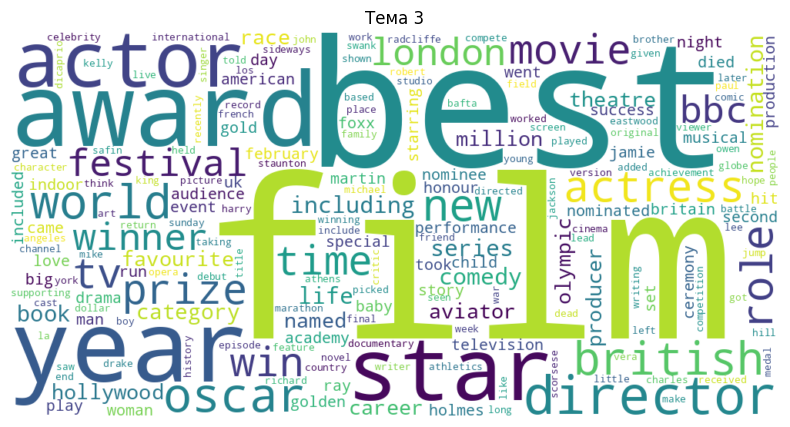

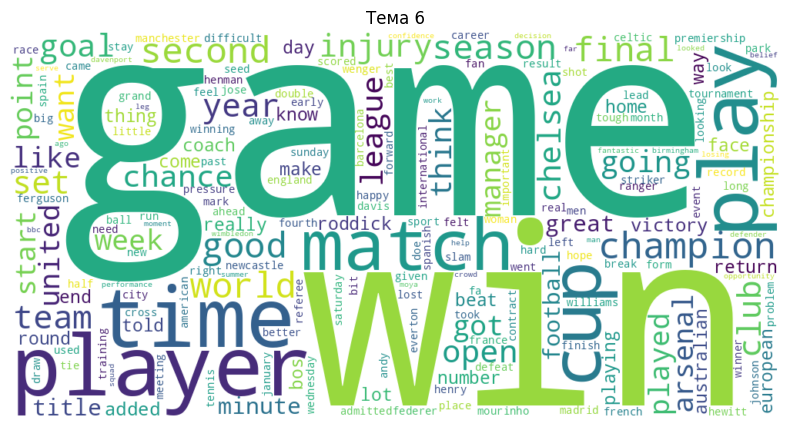

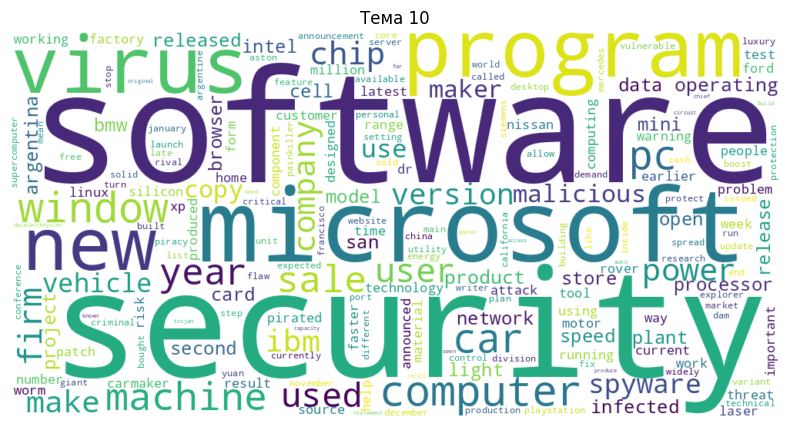

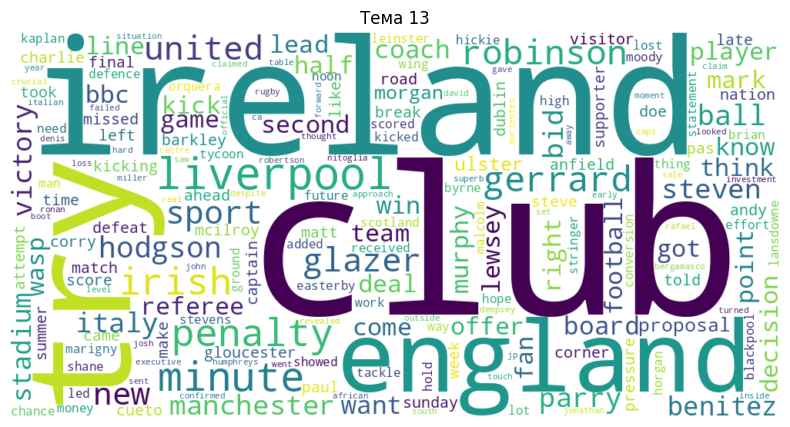

In [37]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud

cv = CountVectorizer(min_df=5, max_df=0.7, ngram_range=(1,1), stop_words='english')
X_bow = cv.fit_transform(data['text'])
terms = cv.get_feature_names_out()

n_components = 16
lda = LatentDirichletAllocation(
  n_components=n_components,
  random_state=42,
  learning_method='batch',
  max_iter=20
)
lda.fit(X_bow)

doc_topic = lda.transform(X_bow)
data['lda_cluster'] = doc_topic.argmax(axis=1)

def print_top_words(model, feature_names, n_top=10):
  for i, topic_vec in enumerate(model.components_):
    top_idx = topic_vec.argsort()[::-1][:n_top]
    print(f"{i:2d}: " + ", ".join(feature_names[top_idx]))

print_top_words(lda, terms, n_top=12)

def topic_wordcloud(topic_id, n_words=200, width=1000, height=500):
  weights = lda.components_[topic_id]
  freqs = {terms[j]: float(weights[j]) for j in np.argsort(weights)[-n_words:]}
  wc = WordCloud(width=width, height=height, background_color='white')
  wc = wc.generate_from_frequencies(freqs)
  plt.figure(figsize=(10,5))
  plt.imshow(wc, interpolation='bilinear')
  plt.axis('off')
  plt.title(f"Тема {topic_id}")
  plt.show()

for tid in [3, 6, 10, 13]:
  topic_wordcloud(tid)

## Часть 2. Transfer learning для задачи классификации текстов

**Задание 2.1 (0.5 балла).** Вспомним, что у нас есть разметка для тематик статей. Попробуем обучить классификатор поверх unsupervised-представлений для текстов. Рассмотрите три модели:

* Логистическая регрессия на tf-idf признаках
* K-Means на tf-idf признаках + логистическая регрессия на расстояниях до центров кластеров
* Латентное размещение Дирихле + логистическая регрессия на вероятностях тем

Разделите выборку на обучающую и тестовую, замерьте accuracy на обоих выборках для всех трех моделей. Параметры всех моделей возьмите равными значениям по умолчанию.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

X_text = data['text'].astype(str).to_numpy()
y = data['category'].astype(str).to_numpy()

Xtr_text, Xte_text, ytr, yte = train_test_split(
    X_text, y, test_size=0.25, random_state=42, stratify=y
)

def acc(y_true, y_pred):
  return accuracy_score(y_true, y_pred)

results = []

tfidf = TfidfVectorizer()
Xtr_tfidf = tfidf.fit_transform(Xtr_text)
Xte_tfidf = tfidf.transform(Xte_text)

clf1 = LogisticRegression()
clf1.fit(Xtr_tfidf, ytr)
results.append(["LogReg(TF-IDF)", acc(ytr, clf1.predict(Xtr_tfidf)), acc(yte, clf1.predict(Xte_tfidf))])

kmeans = KMeans(random_state=42)
kmeans.fit(Xtr_tfidf)
Ztr = kmeans.transform(Xtr_tfidf)
Zte = kmeans.transform(Xte_tfidf)

clf2 = LogisticRegression(max_iter=1000)
clf2.fit(Ztr, ytr)
results.append(["KMeans(TF-IDF)+LogReg(dist)", acc(ytr, clf2.predict(Ztr)), acc(yte, clf2.predict(Zte))])

cv = CountVectorizer()
Xtr_bow = cv.fit_transform(Xtr_text)
Xte_bow = cv.transform(Xte_text)

lda = LatentDirichletAllocation(random_state=42)
lda.fit(Xtr_bow)
Ttr = lda.transform(Xtr_bow)
Tte = lda.transform(Xte_bow)

clf3 = LogisticRegression()
clf3.fit(Ttr, ytr)
results.append(["LDA(BOW)+LogReg(probs)", acc(ytr, clf3.predict(Ttr)), acc(yte, clf3.predict(Tte))])

pd.DataFrame(results, columns=["Модель", "Train acc", "Test acc"])

,Модель,Train acc,Test acc
0,LogReg(TF-IDF),0.997002,0.980251
1,KMeans(TF-IDF)+LogReg(dist),0.805156,0.816876
2,LDA(BOW)+LogReg(probs),0.856115,0.897666


У какой модели получилось лучшее качество? С чем это связано?

**Ответ:** TF-IDF не теряет информации при преобразовании, логрег работает более точно.

**Задание 2.2 (1.5 балла).** Теперь просимулируем ситуацию слабой разметки, которая часто встречается в реальных данных. Разделим обучающую выборку в пропорции 5:65:30. Будем называть части, соответственно, размеченный трейн, неразмеченный трейн и валидация.

Все unsupervised-алгоритмы (векторайзеры и алгоритмы кластеризации) запускайте на всем трейне целиком (размеченном и неразмеченном, суммарно 70%), а итоговый классификатор обучайте только на размеченном трейне (5%). Подберите гиперпараметры моделей по качеству на валидации (30%), а затем оцените качество на тестовой выборке (которая осталась от прошлого задания). Не скромничайте при подборе числа кластеров, сейчас нас интересует не интерпретируемое разбиение выборки, а итоговое качество классификации.

In [39]:
RND = 42

X_all = data['text'].astype(str).to_numpy()
y_all = data['category'].astype(str).to_numpy()

X_trval_text, X_te_text, y_trval, y_te = train_test_split(
    X_all, y_all, test_size=0.25, random_state=RND, stratify=y_all
)

X_tr70_text, X_val_text, y_tr70, y_val = train_test_split(
    X_trval_text, y_trval, test_size=0.30, random_state=RND, stratify=y_trval
)
lab_ratio = 5/70
X_lab_text, X_unlab_text, y_lab, _ = train_test_split(
    X_tr70_text, y_tr70, test_size=1-lab_ratio, random_state=RND, stratify=y_tr70
)

def acc(y_true, y_pred):
  return accuracy_score(y_true, y_pred)

results = []

best_score_tfidf = -1.0
best_model_tfidf = None

for tfidf_params in [
    dict(min_df=3, max_df=0.9, sublinear_tf=True),
    dict(min_df=5, max_df=0.7, sublinear_tf=False),
]:
  tfidf = TfidfVectorizer(ngram_range=(1,1), **tfidf_params)
  Xt70 = tfidf.fit_transform(np.concatenate([X_lab_text, X_unlab_text]))
  Xlab = tfidf.transform(X_lab_text)
  Xval = tfidf.transform(X_val_text)

  for C in [0.5, 1.0, 2.0]:
    clf = LogisticRegression(max_iter=1000, C=C)
    clf.fit(Xlab, y_lab)
    val_acc = acc(y_val, clf.predict(Xval))
    if val_acc > best_score_tfidf:
      best_score_tfidf = val_acc
      best_model_tfidf = (tfidf, clf)

tfidf_best, clf_best = best_model_tfidf
Xte = tfidf_best.transform(X_te_text)
results.append(["TF-IDF, LogReg", best_score_tfidf, acc(y_te, clf_best.predict(Xte))])

best_score_km = -1.0
best_bundle_km = None

tfidf2 = TfidfVectorizer()
Xt70 = tfidf2.fit_transform(np.concatenate([X_lab_text, X_unlab_text]))
Xlab = tfidf2.transform(X_lab_text)
Xval = tfidf2.transform(X_val_text)

for k in [20, 40, 60, 80, 100]:
  km = KMeans(n_clusters=k, random_state=RND)
  km.fit(Xt70)
  Zlab = km.transform(Xlab)
  Zval = km.transform(Xval)
  for C in [0.5, 1.0, 2.0]:
    clf = LogisticRegression(max_iter=1000, C=C)
    clf.fit(Zlab, y_lab)
    val_acc = acc(y_val, clf.predict(Zval))
    if val_acc > best_score_km:
      best_score_km = val_acc
      best_bundle_km = (tfidf2, km, clf)

tfidf2_best, km_best, clf2_best = best_bundle_km
Zte = km_best.transform(tfidf2_best.transform(X_te_text))
results.append(["TF-IDF, KMeans, LogReg", best_score_km, acc(y_te, clf2_best.predict(Zte))])

best_score_lda = -1.0
best_bundle_lda = None

cv = CountVectorizer()
Xt70_bow = cv.fit_transform(np.concatenate([X_lab_text, X_unlab_text]))
Xlab_bow = cv.transform(X_lab_text)
Xval_bow = cv.transform(X_val_text)

for n_topics in [20, 40, 60, 80]:
  lda = LatentDirichletAllocation(n_components=n_topics, random_state=RND)
  lda.fit(Xt70_bow)
  Tlab = lda.transform(Xlab_bow)
  Tval = lda.transform(Xval_bow)
  for C in [0.5, 1.0, 2.0]:
    clf = LogisticRegression(max_iter=1000, C=C)
    clf.fit(Tlab, y_lab)
    val_acc = acc(y_val, clf.predict(Tval))
    if val_acc > best_score_lda:
      best_score_lda = val_acc
      best_bundle_lda = (cv, lda, clf)
cv_best, lda_best, clf3_best = best_bundle_lda
Tte = lda_best.transform(cv_best.transform(X_te_text))
results.append(["BOW, LDA, probs, LogReg", best_score_lda, acc(y_te, clf3_best.predict(Tte))])

out = pd.DataFrame(results, columns=["Модель", "Val acc (подбор)", "Test acc"]).sort_values("Test acc", ascending=False)
out

,Модель,Val acc (подбор),Test acc
0,"TF-IDF, LogReg",0.924152,0.921005
2,"BOW, LDA, probs, LogReg",0.896208,0.899461
1,"TF-IDF, KMeans, LogReg",0.828343,0.843806


Как изменились результаты по сравнению с обучением на полной разметке? Сделайте выводы.

**Ответ:** Результаты стали хуже, что ожидаемо, но всё равно TF-IDF + логрег работают лучше.

**Задание 3 (1 балл)**. Разберитесь с semi-supervised методами, которые реализованы в `sklearn` и примените их к заданию 3.2. Получилось ли добиться лучшего качества? Сделайте выводы.

In [ ]:
# YOUR CODE HERE ‿︵‿︵ヽ(°□° )ノ︵‿︵‿

**Задание 4 (1 балл)**. Есть такая метрика [BCubed](https://www.researchgate.net/profile/Julio-Gonzalo-2/publication/225548032_Amigo_E_Gonzalo_J_Artiles_J_et_alA_comparison_of_extrinsic_clustering_evaluation_metrics_based_on_formal_constraints_Inform_Retriev_12461-486/links/0c96052138dbb99740000000/Amigo-E-Gonzalo-J-Artiles-J-et-alA-comparison-of-extrinsic-clustering-evaluation-metrics-based-on-formal-constraints-Inform-Retriev-12461-486.pdf) хорошо подходит для сравнения алгоритмов кластеризации, если нам известно настоящее разделение на кластеры (gold standard). Реализуйте подсчет метрики BCubed и сравните несколько алгоритмов кластеризации на текстовых данных из основного задания. В качестве gold standard используйте разметку category.

In [ ]:
# YOUR CODE HERE ‿︵‿︵ヽ(°□° )ノ︵‿︵‿